# Model Explainability - Predictive Healthcare Analytics

This notebook focuses on interpreting the final CatBoost model using SHAP.
The goal is to understand which features contribute most to the model's predictions
and improve transparency of the healthcare risk prediction system.

## Cell 2 — Import Libraries ##

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

import joblib

import warnings
warnings.filterwarnings("ignore")

## Cell 3 — Load Final Model ##

In [11]:
model_path = "../models/catboost.pkl"

model = joblib.load(model_path)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['num_lab_procedures',
                                                   'num_medications',
                                                   'time_in_hospital', 'age',
                                                   'discharge_disposition_id',
                                                   'number_diagnoses',
                                                   'num_procedures',
                                                   'total_visits',
                                                   'admission_type_id',
                                                   'number_inpatient',
                                                   'admission_source_id',
                                                   'active_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'changed_medications']),
                                                 ('categorical',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['diag_1', 'diag_2', 'diag_3',
                                                   'race', 'insulin', 'gender',
                                                   'metformin', 'glipizide',
                                                   'glyburide', 'change',
                                                   'pioglitazone',
                                                   'rosiglitazone',
                                                   'glimepiride'])])),
                ('model', CatBoostClassifier(random_state=42, verbose=0))])

## Cell 4 — Load Dataset ##
## Load Test Data

The test dataset is loaded to analyze model predictions and interpret feature contributions.

In [12]:
data_path = "../data/processed/selected_data.csv"

df = pd.read_csv(data_path)

df.head()

,num_lab_procedures,diag_1,diag_2,diag_3,num_medications,time_in_hospital,age,discharge_disposition_id,number_diagnoses,num_procedures,...,metformin,glipizide,glyburide,number_emergency,changed_medications,change,pioglitazone,rosiglitazone,glimepiride,readmitted
0,41,250.83,NaN,NaN,1,1,5,25,1,0,...,No,No,No,0,0,No,No,No,No,0
1,59,276,250.01,255,18,3,15,1,9,0,...,No,No,No,0,1,Ch,No,No,No,1
2,11,648,250,V27,13,2,25,1,6,5,...,No,Steady,No,0,0,No,No,No,No,0
3,44,8,250.43,403,16,2,35,1,7,1,...,No,No,No,0,1,Ch,No,No,No,0
4,51,197,157,250,8,1,45,1,5,0,...,No,Steady,No,0,0,Ch,No,No,No,0


## Cell 5 — Prepare Data for Explanation ##
## Prepare Data for SHAP Analysis

The input data is prepared using the same feature set used during model training.
The preprocessing steps are handled automatically by the saved pipeline.

In [13]:
# Separate features and target

target = "readmitted"

X = df.drop(columns=[target])
y = df[target]


# Check dimensions

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (101766, 28)
Target shape: (101766,)


In [14]:
# Get feature names used by the model

model.feature_names_in_

array(['num_lab_procedures', 'diag_1', 'diag_2', 'diag_3',
       'num_medications', 'time_in_hospital', 'age',
       'discharge_disposition_id', 'number_diagnoses', 'num_procedures',
       'total_visits', 'admission_type_id', 'number_inpatient', 'race',
       'insulin', 'admission_source_id', 'active_medications', 'gender',
       'number_outpatient', 'metformin', 'glipizide', 'glyburide',
       'number_emergency', 'changed_medications', 'change',
       'pioglitazone', 'rosiglitazone', 'glimepiride'], dtype=object)

## Cell 6 — Extract Pipeline Components ##
## Extract CatBoost Model

The trained CatBoost model is extracted from the pipeline.
The preprocessing pipeline is applied separately to transform input data.

In [15]:
# Extract preprocessing and CatBoost model

preprocessor = model.named_steps["preprocessor"]

catboost_model = model.named_steps["model"]


catboost_model

CatBoostClassifier(random_state=42, verbose=0)

In [16]:
# Transform data using preprocessing pipeline

X_transformed = preprocessor.transform(X)

X_transformed.shape

(101766, 2239)

In [18]:
# Extract CatBoost model from pipeline

catboost_model = model.named_steps["model"]

# Get feature importance
feature_importance = catboost_model.get_feature_importance()

feature_importance[:10]

array([ 5.03697858,  4.27810235,  3.57546597,  4.77809749, 20.26178238,
        4.25753691,  2.80911341,  7.95947821,  3.21027517,  8.55445545])

In [20]:
# Get feature names after preprocessing

feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names[:10]

array(['numeric__num_lab_procedures', 'numeric__num_medications',
       'numeric__time_in_hospital', 'numeric__age',
       'numeric__discharge_disposition_id', 'numeric__number_diagnoses',
       'numeric__num_procedures', 'numeric__total_visits',
       'numeric__admission_type_id', 'numeric__number_inpatient'],
      dtype=object)

## Cell 10 ##

In [21]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df.head()


,Feature,Importance
0,numeric__num_lab_procedures,5.036979
1,numeric__num_medications,4.278102
2,numeric__time_in_hospital,3.575466
3,numeric__age,4.778097
4,numeric__discharge_disposition_id,20.261782


## Cell 11 - Feature Importance ##

In [22]:
# Sort features by importance

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
4,numeric__discharge_disposition_id,20.261782
9,numeric__number_inpatient,8.554455
7,numeric__total_visits,7.959478
0,numeric__num_lab_procedures,5.036979
10,numeric__admission_source_id,4.825686
3,numeric__age,4.778097
1,numeric__num_medications,4.278102
5,numeric__number_diagnoses,4.257537
2,numeric__time_in_hospital,3.575466
8,numeric__admission_type_id,3.210275


## Code Cell 12 — Visualization: Top 20 Feature Importance ##

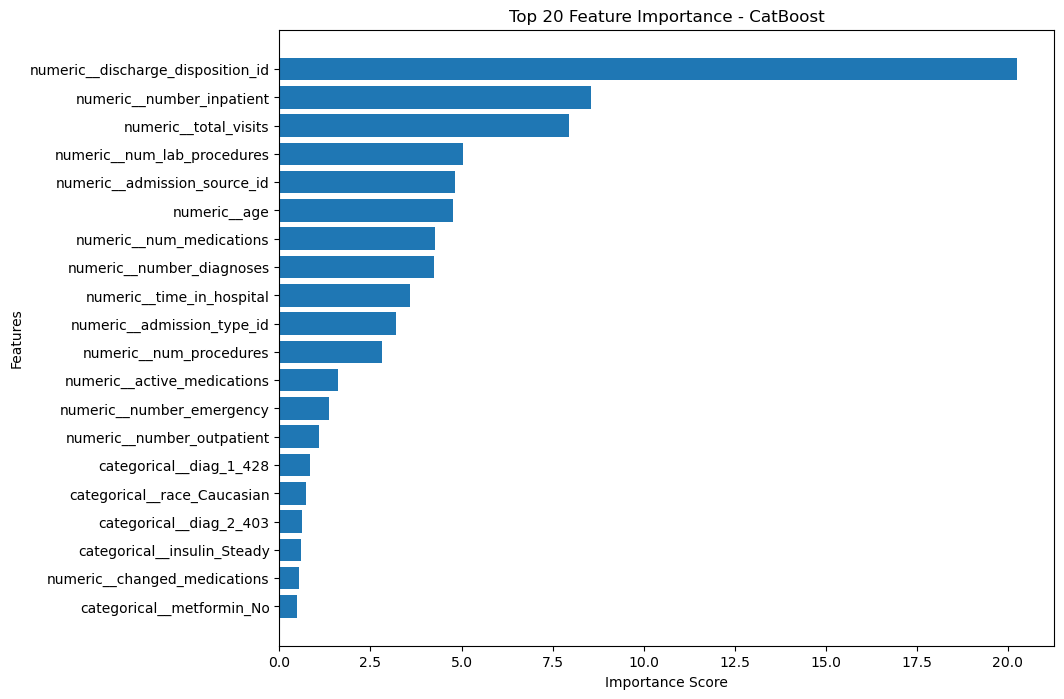

In [23]:
import matplotlib.pyplot as plt

# Select top 20 features
top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Feature Importance - CatBoost")

plt.gca().invert_yaxis()

plt.show()

## Model Evaluation Summary

The final CatBoost model was evaluated using multiple classification metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, and Classification Report.

All evaluation results were previously generated and stored in the `reports/` directory.

Based on the comparison between different machine learning models, CatBoost achieved the best overall performance and was selected as the final baseline model.

Further optimization using Optuna hyperparameter tuning was performed; however, the tuned model did not improve the overall performance compared to the original CatBoost model.

Therefore, the original CatBoost model was retained as the final model.